In [43]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
import seaborn as sb 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error

In [44]:
df=pd.read_csv('StudentPerformanceFactors.csv')
df.head()


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [45]:

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns
for col in numeric_cols:
        df[col].fillna(df[col].median(), inplace=True)
for col in categorical_cols:
        df[col].fillna("unknown", inplace=True)


In [46]:
df.isnull().sum()


Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

In [47]:
l=categorical_cols[:]
list(l)

['Parental_Involvement',
 'Access_to_Resources',
 'Extracurricular_Activities',
 'Motivation_Level',
 'Internet_Access',
 'Family_Income',
 'Teacher_Quality',
 'School_Type',
 'Peer_Influence',
 'Learning_Disabilities',
 'Parental_Education_Level',
 'Distance_from_Home',
 'Gender']

In [48]:
le=LabelEncoder()
for i in l:
    
    df[i]=le.fit_transform(df[i])


In [49]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,1,0,0,7,73,1,1,0,1,2,1,2,3,0,1,2,1,67
1,19,64,1,2,0,8,59,1,1,2,2,2,1,0,4,0,0,1,0,61
2,24,98,2,2,1,7,91,2,1,2,2,2,1,1,4,0,2,2,1,74
3,29,89,1,2,1,8,98,2,1,1,2,2,1,0,4,0,1,1,1,71
4,19,92,2,2,1,6,65,2,1,3,2,0,1,1,4,0,0,2,0,70


In [50]:
y=df['Exam_Score']
x=df.drop(columns=['Exam_Score'])
sc=StandardScaler()
x=sc.fit_transform(x)


In [51]:
train_x,test_x,train_y,test_y=train_test_split(x,y,test_size=0.2,random_state=42)

In [52]:
model=LinearRegression()
model.fit(train_x,train_y)

LinearRegression()

In [53]:
y_pred=model.predict(test_x)
print("RMSE:", np.sqrt(mean_squared_error(test_y,y_pred)))
print("R²:", r2_score(test_y, y_pred))

RMSE: 2.0979483598160753
R²: 0.6886194019277319


In [54]:
from sklearn.model_selection import cross_val_score
import numpy as np

scores = cross_val_score(model, x, y, cv=5, scoring="r2")
print("Cross-validation R²:", np.mean(scores))

Cross-validation R²: 0.6499507940054754


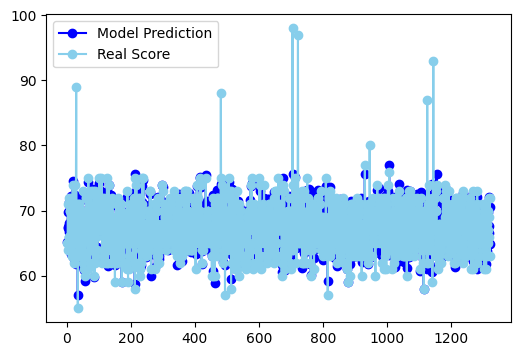

In [55]:
import matplotlib.pylab as plt
range1=range(1,len(y_pred)+1)
plt.figure(figsize=(6,4))
plt.plot(range1,y_pred,"o-",color="blue",label="Model Prediction")
plt.plot(range1,test_y,"o-",color="skyblue",label="Real Score")
plt.legend()
plt.show()

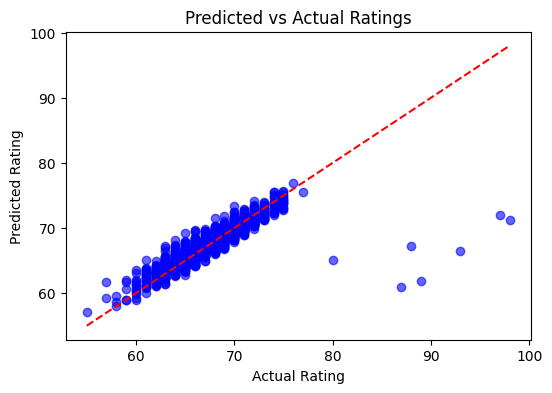

In [56]:
plt.figure(figsize=(6,4))
plt.scatter(test_y,y_pred,color="blue",alpha=0.6)
plt.plot([test_y.min(),test_y.max()],[test_y.min(),test_y.max()],"r--")
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Predicted vs Actual Ratings")
plt.show()

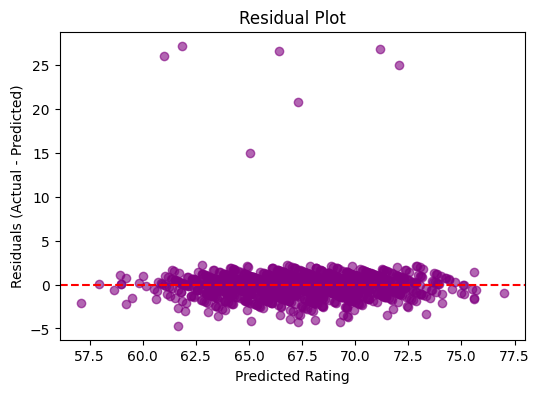

In [57]:
residuals = test_y - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.6, color="purple")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Rating")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()